In [ ]:
!pip install scikit-learn joblib pandas openpyxl

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()
excel_file = list(uploaded.keys())[0]

df = pd.read_excel(excel_file)
print(f"✅ Dataset loaded: {df.shape[0]} videos, {df.shape[1]} columns")
print("\nAudio Label distribution:")
print(df['Audio_Label'].value_counts())

Saving complete_dataset.xlsx to complete_dataset.xlsx
✅ Dataset loaded: 73 videos, 25 columns

Audio Label distribution:
Audio_Label
neutral      22
sad          13
sarcasm       9
anxious       9
depressed     8
happy         8
fear          2
disgust       1
angry         1
Name: count, dtype: int64


In [ ]:
feature_cols = [f'MFCC_{i+1}' for i in range(13)] + ['ZCR', 'RMS', 'Avg_Pitch']

# Drop rows with missing features
df_clean = df.dropna(subset=feature_cols + ['Audio_Label'])
print(f"✅ Clean samples: {len(df_clean)}")

X = df_clean[feature_cols].values
y_raw = df_clean['Audio_Label'].values

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y_raw)

print(f"\n🏷️ Classes: {le.classes_}")
print(f"📊 Class distribution:")
for cls, count in zip(*np.unique(y_raw, return_counts=True)):
    print(f"   {cls}: {count}")

✅ Clean samples: 73

🏷️ Classes: ['angry' 'anxious' 'depressed' 'disgust' 'fear' 'happy' 'neutral' 'sad'
 'sarcasm']
📊 Class distribution:
   angry: 1
   anxious: 9
   depressed: 8
   disgust: 1
   fear: 2
   happy: 8
   neutral: 22
   sad: 13
   sarcasm: 9


In [ ]:
# Merge rare classes (fear, disgust, angry → sad)
# since they have only 1-2 samples each
rare_map = {
    'fear': 'sad',
    'disgust': 'sad',
    'angry': 'sad'
}

df_clean = df_clean.copy()
df_clean['Audio_Label_Clean'] = df_clean['Audio_Label'].replace(rare_map)

print("✅ After merging rare classes:")
print(df_clean['Audio_Label_Clean'].value_counts())

X = df_clean[feature_cols].values
y_raw = df_clean['Audio_Label_Clean'].values
le = LabelEncoder()
y = le.fit_transform(y_raw)

✅ After merging rare classes:
Audio_Label_Clean
neutral      22
sad          17
sarcasm       9
anxious       9
depressed     8
happy         8
Name: count, dtype: int64


In [ ]:
# Stratified train/test split to maintain class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")

# Train Random Forest
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=3,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced'  # handles class imbalance
)

model.fit(X_train, y_train)
print("\n✅ Model trained!")

# Test accuracy
y_pred = model.predict(X_test)
print(f"\n📈 Test Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Training samples: 58
Test samples:     15

✅ Model trained!

📈 Test Accuracy: 20.00%

📊 Classification Report:
              precision    recall  f1-score   support

     anxious       0.33      0.50      0.40         2
   depressed       0.50      0.50      0.50         2
       happy       0.00      0.00      0.00         2
     neutral       0.00      0.00      0.00         4
         sad       0.00      0.00      0.00         3
     sarcasm       0.17      0.50      0.25         2

    accuracy                           0.20        15
   macro avg       0.17      0.25      0.19        15
weighted avg       0.13      0.20      0.15        15



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# More reliable accuracy estimate on small dataset
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

print("📊 5-Fold Cross Validation Results:")
print(f"   Scores : {[round(s, 3) for s in cv_scores]}")
print(f"   Mean   : {cv_scores.mean():.2%}")
print(f"   Std Dev: {cv_scores.std():.2%}")

📊 5-Fold Cross Validation Results:
   Scores : [np.float64(0.333), np.float64(0.267), np.float64(0.333), np.float64(0.429), np.float64(0.357)]
   Mean   : 34.38%
   Std Dev: 5.20%


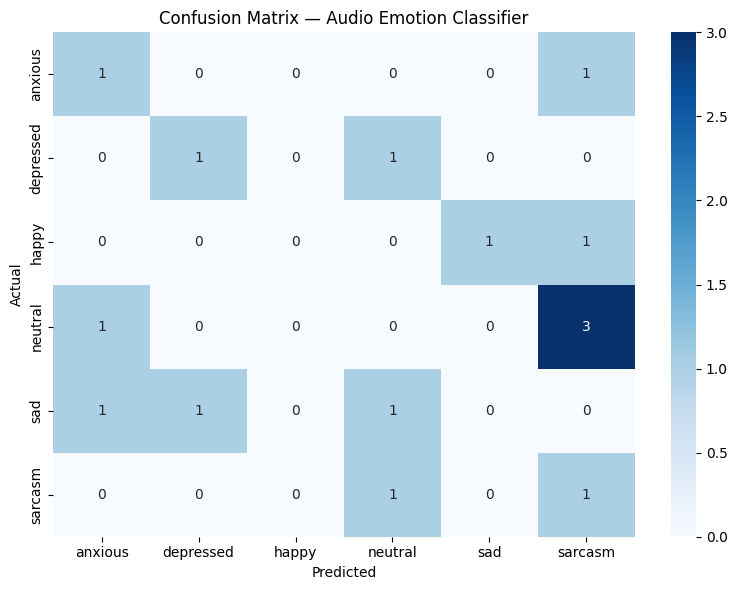

✅ Confusion matrix saved!


In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix — Audio Emotion Classifier')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved!")

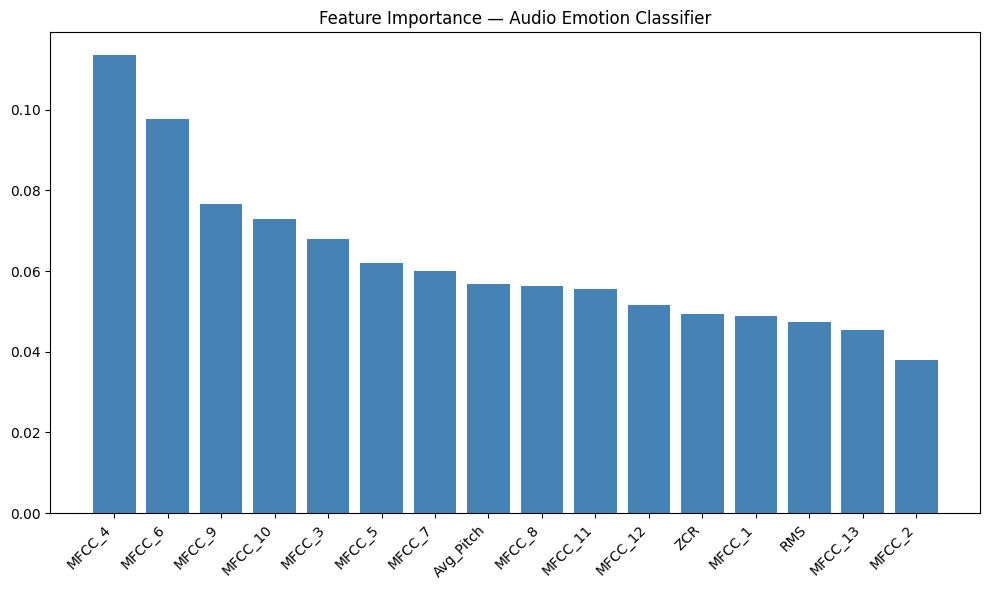

✅ Feature importance saved!


In [ ]:
importances = model.feature_importances_
feature_names = feature_cols

plt.figure(figsize=(10, 6))
indices = np.argsort(importances)[::-1]
plt.bar(range(len(feature_cols)), importances[indices], color='steelblue')
plt.xticks(range(len(feature_cols)),
           [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Feature Importance — Audio Emotion Classifier')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("✅ Feature importance saved!")

In [ ]:
joblib.dump(model, 'audio_emotion_model.pkl')
joblib.dump(le, 'label_encoder.pkl')

files.download('audio_emotion_model.pkl')
files.download('label_encoder.pkl')
print("✅ Model and encoder saved!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model and encoder saved!


In [ ]:
# Test prediction on first row
sample = df_clean[feature_cols].iloc[0].values.reshape(1, -1)
pred = model.predict(sample)[0]
emotion = le.inverse_transform([pred])[0]
actual = df_clean['Audio_Label_Clean'].iloc[0]

print(f"Video    : {df_clean['Video Name'].iloc[0]}")
print(f"Actual   : {actual}")
print(f"Predicted: {emotion}")
print(f"Match    : {'✅' if actual == emotion else '❌'}")

Video    : VID_20260305_230632.mp4
Actual   : sad
Predicted: sad
Match    : ✅


In [ ]:
# ── PREDICT AUDIO EMOTION & SCORE FOR ALL VIDEOS ──

audio_score_map = {
    'depressed' : -4,
    'anxious'   : -3,
    'nervous'   : -3,
    'sad'       : -2,
    'sarcasm'   : -2,
    'neutral'   :  0,
    'surprise'  :  1,
    'happy'     :  2
}

audio_emotions  = []
audio_scores    = []

for _, row in df_clean.iterrows():
    features = row[feature_cols].values.reshape(1, -1)

    # Predict emotion
    pred_encoded = model.predict(features)[0]
    predicted_emotion = le.inverse_transform([pred_encoded])[0]

    # Get score
    predicted_score = audio_score_map.get(predicted_emotion, 0)

    audio_emotions.append(predicted_emotion)
    audio_scores.append(predicted_score)

# Add to dataframe
df_clean = df_clean.copy()
df_clean['Audio_Emotion']       = audio_emotions
df_clean['Audio_Emotion_Score'] = audio_scores

# Show results
print("✅ Audio emotions predicted for all videos\n")
print(df_clean[['Video Name', 'Audio_Label_Clean', 'Audio_Emotion',
                'Audio_Emotion_Score']].to_string(index=False))

print("\n📊 Predicted Audio Emotion Distribution:")
print(df_clean['Audio_Emotion'].value_counts())

In [ ]:
# ── EXPORT FINAL DATASET WITH AUDIO PREDICTIONS ──

output_cols = [
    'Video Name',
    'Transcription',
    'Emotion',              # text emotion
    'Emotion_Score',        # text score
    'Facial_Emotion',       # facial emotion
    'Facial_Emotion_Score', # facial score
    'Audio_Emotion',        # audio predicted emotion
    'Audio_Emotion_Score',  # audio predicted score
    'Audio_Label_Clean',    # conservative training label
    'Audio_Label_Score',    # conservative label score
]

df_final = df_clean[output_cols].copy()

# ── WEIGHTED FINAL SCORE ──
df_final['Final_Score'] = (
    0.4 * df_final['Emotion_Score'] +
    0.3 * df_final['Facial_Emotion_Score'] +
    0.3 * df_final['Audio_Emotion_Score']
).round(2)

# ── FINAL ASSESSMENT ──
def get_assessment(score):
    if score >= 1.5:    return "✅ Positive"
    elif score >= 0.5:  return "🟢 Positive"
    elif score >= -0.5: return "🟡 Neutral"
    elif score >= -1.5: return "🟠 Moderate Risk"
    else:               return "🔴 High Risk"

df_final['Final_Assessment'] = df_final['Final_Score'].apply(get_assessment)

# Show final results
print("✅ Final dataset ready\n")
print(df_final[['Video Name', 'Emotion', 'Facial_Emotion',
                'Audio_Emotion', 'Final_Score',
                'Final_Assessment']].to_string(index=False))

print(f"\n📊 Final Assessment Distribution:")
print(df_final['Final_Assessment'].value_counts())

# Export
df_final.to_excel('final_emotion_analysis.xlsx', index=False)
files.download('final_emotion_analysis.xlsx')
print("\n✅ Final dataset saved and downloaded!")

In [ ]:
# ── COMPLETE DATASET WITH ALL STAGES ──

# Merge audio predictions back to original df
df_complete = df.copy()

# Add cleaned audio label
df_complete['Audio_Label_Clean'] = df_complete['Audio_Label'].replace({
    'fear': 'sad', 'disgust': 'sad', 'angry': 'sad'
})

# Add audio emotion predictions and scores
df_complete['Audio_Emotion'] = df_clean['Audio_Emotion'].values
df_complete['Audio_Emotion_Score'] = df_clean['Audio_Emotion_Score'].values

# Weighted final score
df_complete['Final_Score'] = (
    0.4 * df_complete['Emotion_Score'] +
    0.3 * df_complete['Facial_Emotion_Score'] +
    0.3 * df_complete['Audio_Emotion_Score']
).round(2)

# Final assessment
def get_assessment(score):
    if score >= 1.5:    return "Positive"
    elif score >= 0.5:  return "Positive"
    elif score >= -0.5: return "Neutral"
    elif score >= -1.5: return "Moderate Risk"
    else:               return "High Risk"

df_complete['Final_Assessment'] = df_complete['Final_Score'].apply(get_assessment)

# ── COLUMN ORDER ──
output_cols = [
    # Video info
    'Video Name',
    'Transcription',

    # Stage 1 - Text
    'Emotion',
    'Emotion_Score',

    # Stage 2 - Facial
    'Facial_Emotion',
    'Facial_Emotion_Score',
    'Facial_Emotion_Breakdown',

    # Stage 3 - Audio Features
    'MFCC_1', 'MFCC_2', 'MFCC_3', 'MFCC_4', 'MFCC_5',
    'MFCC_6', 'MFCC_7', 'MFCC_8', 'MFCC_9', 'MFCC_10',
    'MFCC_11', 'MFCC_12', 'MFCC_13',
    'ZCR', 'RMS', 'Avg_Pitch',

    # Stage 3 - Audio Labels & Prediction
    'Audio_Label',
    'Audio_Label_Score',
    'Audio_Label_Clean',
    'Audio_Emotion',
    'Audio_Emotion_Score',

    # Final
    'Final_Score',
    'Final_Assessment'
]

df_complete = df_complete[output_cols]

print(f"✅ Complete dataset: {df_complete.shape[0]} videos, {df_complete.shape[1]} columns")
print("\nColumns included:")
for i, col in enumerate(output_cols, 1):
    print(f"  {i:2}. {col}")

# Export
df_complete.to_excel('complete_final_dataset.xlsx', index=False)
files.download('complete_final_dataset.xlsx')
print("\n✅ Complete dataset saved and downloaded!")

✅ Complete dataset: 73 videos, 30 columns

Columns included:
   1. Video Name
   2. Transcription
   3. Emotion
   4. Emotion_Score
   5. Facial_Emotion
   6. Facial_Emotion_Score
   7. Facial_Emotion_Breakdown
   8. MFCC_1
   9. MFCC_2
  10. MFCC_3
  11. MFCC_4
  12. MFCC_5
  13. MFCC_6
  14. MFCC_7
  15. MFCC_8
  16. MFCC_9
  17. MFCC_10
  18. MFCC_11
  19. MFCC_12
  20. MFCC_13
  21. ZCR
  22. RMS
  23. Avg_Pitch
  24. Audio_Label
  25. Audio_Label_Score
  26. Audio_Label_Clean
  27. Audio_Emotion
  28. Audio_Emotion_Score
  29. Final_Score
  30. Final_Assessment


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Complete dataset saved and downloaded!
